# ASL Dataset - Exploratory Data Analysis

This notebook covers:
1. Class distribution per dataset and combined
2. Image statistics (dimensions, aspect ratio, brightness, channel means)
3. Per-class sample grids
4. Augmentation justification (why horizontal/vertical flips are excluded)
5. Class-weight derivation for imbalance-aware loss
6. Raw dataset class counts per source

In [27]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path('.').resolve().parent / 'src'))

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from PIL import Image
from tqdm.notebook import tqdm

from config import load_config

cfg = load_config('../configs/config.yaml')
print(f'Environment: {cfg.env}')
print(f'Data root: {cfg.data_root}')
print(f'Classes: {len(cfg.classes)} - {cfg.classes}')

[config] environment: local
Environment: local
Data root: data
Classes: 37 - ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'nothing']


## 1. Raw manifest - class distribution per dataset

Total images: 157,646
Sources: ['combine_asl' 'asl_hg_raw' 'asl_alphabet']
Classes: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'nothing']


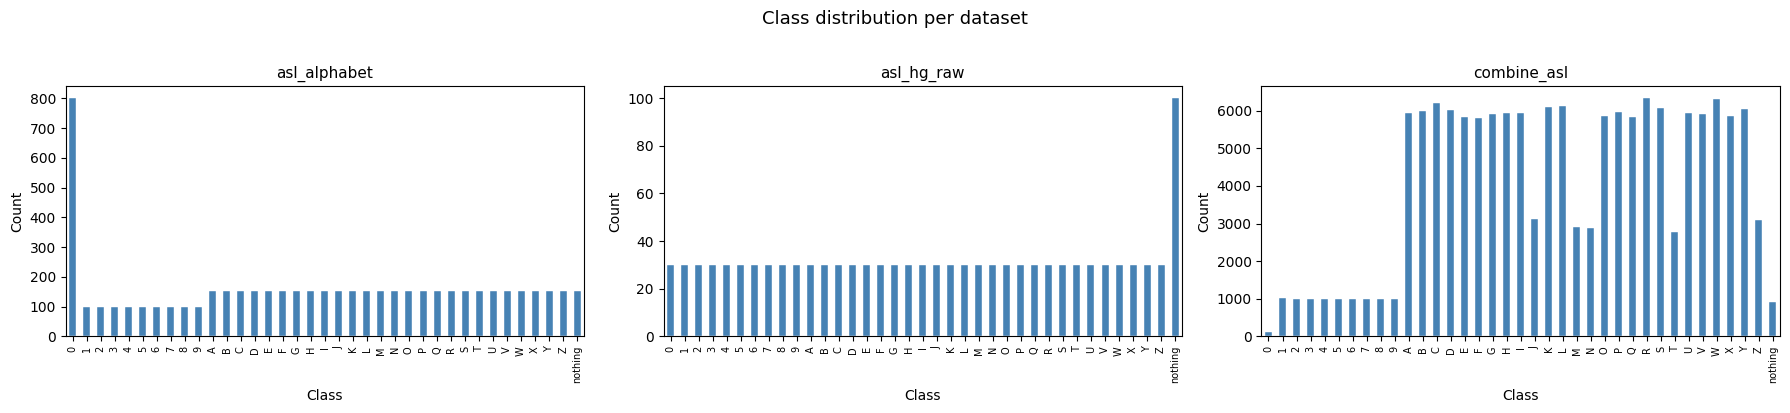

In [28]:
manifest_path = '..' / cfg.data_root / 'manifest_raw.csv'
if not manifest_path.exists():
    print('Manifest not found. Run data_unification.py first.')
else:
    df = pd.read_csv(manifest_path)
    print(f'Total images: {len(df):,}')
    print(f'Sources: {df["source_dataset"].unique()}')
    print(f'Classes: {sorted(df["class_name"].unique())}')

    # Per-source counts
    fig, axes = plt.subplots(1, len(df['source_dataset'].unique()), figsize=(18, 4), sharey=False)
    for ax, (src, sub) in zip(axes, df.groupby('source_dataset')):
        counts = sub.groupby('class_name').size().reindex(cfg.classes, fill_value=0)
        counts.plot.bar(ax=ax, color='steelblue', edgecolor='white', linewidth=0.3)
        ax.set_title(src, fontsize=11)
        ax.set_xlabel('Class')
        ax.set_ylabel('Count')
        ax.tick_params(axis='x', labelsize=7, rotation=90)
    plt.suptitle('Class distribution per dataset', y=1.02, fontsize=13)
    plt.tight_layout()
    plt.show()

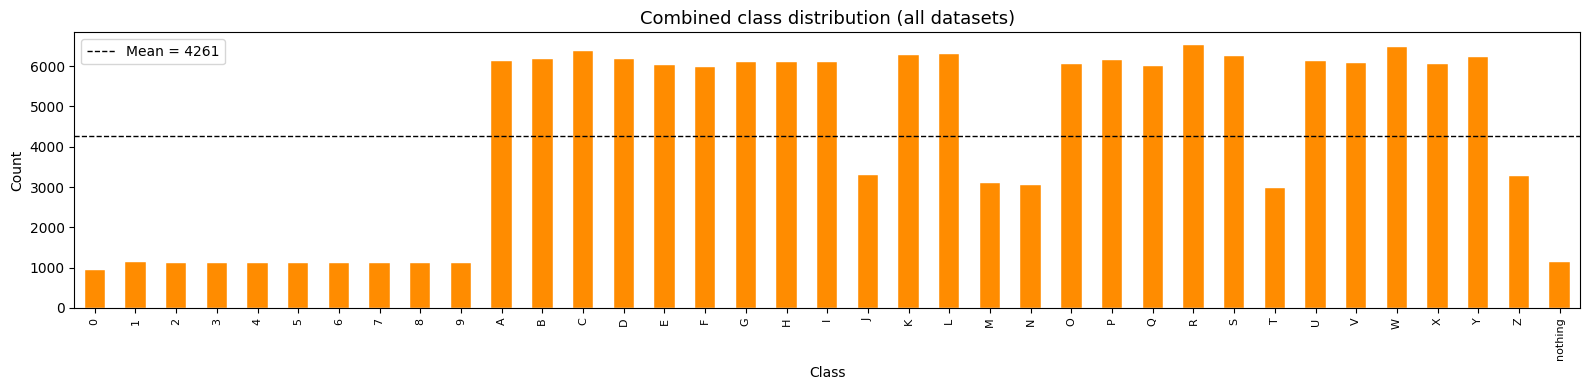

Imbalance ratio (max/min): 6.9x
Most common: R (6,512)
Least common: 0 (950)


In [29]:
# Combined distribution
df = pd.read_csv(manifest_path)  # reload to ensure all data is included
combined = df.groupby('class_name').size().reindex(cfg.classes, fill_value=0)

fig, ax = plt.subplots(figsize=(16, 4))
combined.plot.bar(ax=ax, color='darkorange', edgecolor='white', linewidth=0.3)
ax.axhline(combined.mean(), color='black', linestyle='--', linewidth=1, label=f'Mean = {combined.mean():.0f}')
ax.set_title('Combined class distribution (all datasets)', fontsize=13)
ax.set_xlabel('Class')
ax.set_ylabel('Count')
ax.tick_params(axis='x', labelsize=8, rotation=90)
ax.legend()
plt.tight_layout()
plt.show()

imbalance_ratio = combined.max() / combined.min()
print(f'Imbalance ratio (max/min): {imbalance_ratio:.1f}x')
print(f'Most common: {combined.idxmax()} ({combined.max():,})')
print(f'Least common: {combined.idxmin()} ({combined.min():,})')

## 2. Image statistics

Image stats:   0%|          | 0/2000 [00:00<?, ?it/s]

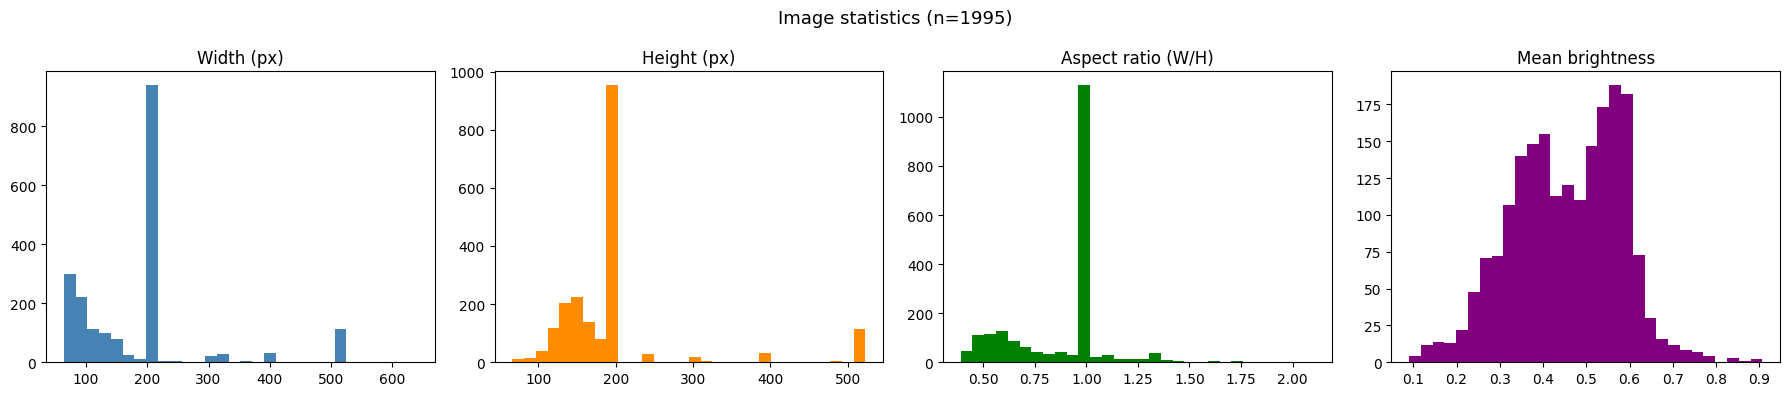

Width: 183 ± 104 px
Height: 201 ± 91 px
Channel means (R/G/B): 0.495 / 0.434 / 0.437


In [30]:
SAMPLE_N = 2000  # sample for speed
sample = df.sample(min(SAMPLE_N, len(df)), random_state=42)

widths, heights, aspects, brightnesses = [], [], [], []
ch_means = [[], [], []]

for path in tqdm(sample['filepath'], desc='Image stats'):
    try:
        with Image.open(path) as img:
            w, h = img.size
            widths.append(w)
            heights.append(h)
            aspects.append(w / h)
            arr = np.array(img.convert('RGB'), dtype=np.float32) / 255.0
            brightnesses.append(arr.mean())
            for c in range(3):
                ch_means[c].append(arr[:, :, c].mean())
    except Exception:
        pass

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
axes[0].hist(widths, bins=30, color='steelblue'); axes[0].set_title('Width (px)')
axes[1].hist(heights, bins=30, color='darkorange'); axes[1].set_title('Height (px)')
axes[2].hist(aspects, bins=30, color='green'); axes[2].set_title('Aspect ratio (W/H)')
axes[3].hist(brightnesses, bins=30, color='purple'); axes[3].set_title('Mean brightness')
plt.suptitle(f'Image statistics (n={len(widths)})', fontsize=13)
plt.tight_layout()
plt.show()

print(f'Width: {np.mean(widths):.0f} ± {np.std(widths):.0f} px')
print(f'Height: {np.mean(heights):.0f} ± {np.std(heights):.0f} px')
print(f'Channel means (R/G/B): {np.mean(ch_means[0]):.3f} / {np.mean(ch_means[1]):.3f} / {np.mean(ch_means[2]):.3f}')

## 3. Per-class sample grids

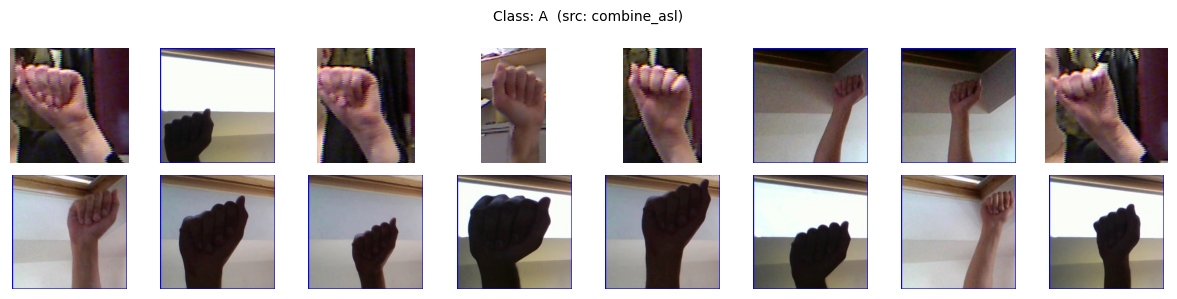

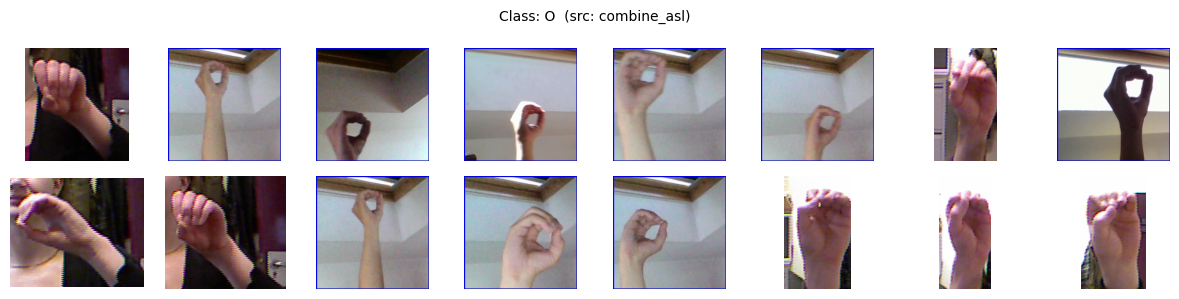

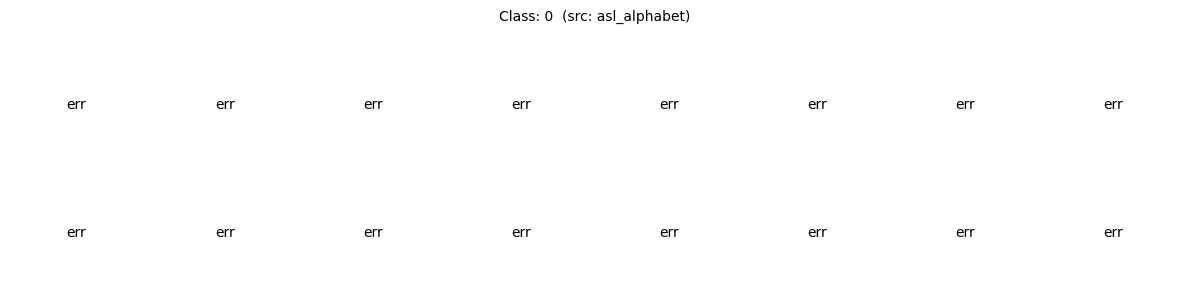

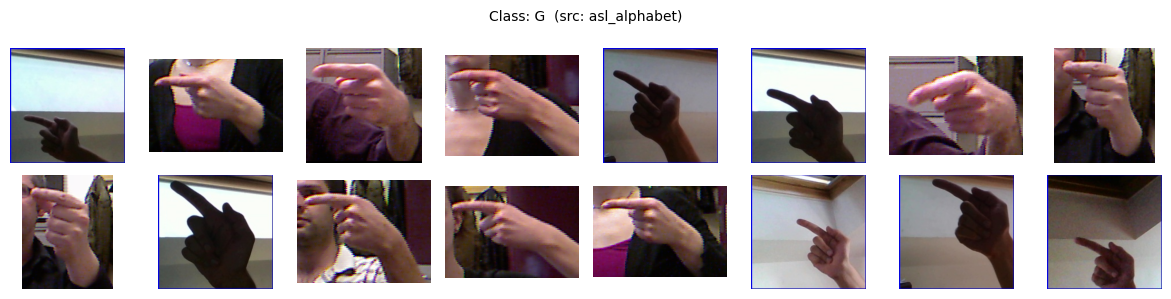

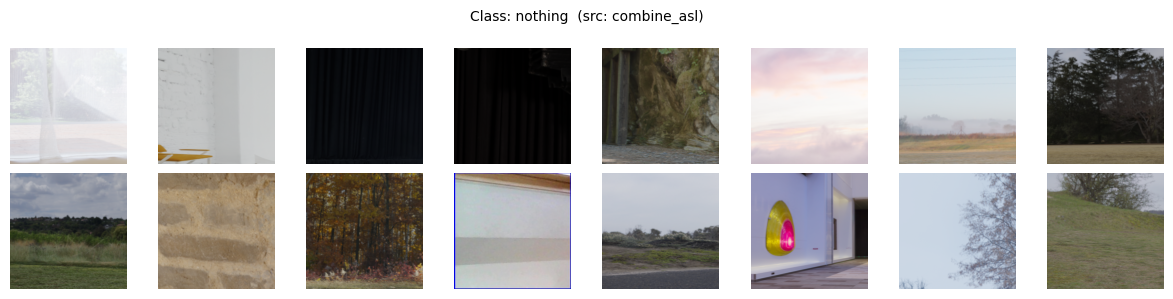

In [31]:
def show_class_grid(df, class_name, n_cols=8, n_rows=2):
    sub = df[df['class_name'] == class_name].sample(min(n_cols * n_rows, len(df[df['class_name'] == class_name])), random_state=42)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 1.5, n_rows * 1.5))
    axes = axes.flatten()
    for ax, (_, row) in zip(axes, sub.iterrows()):
        try:
            img = Image.open(row['filepath']).convert('RGB')
            ax.imshow(img)
        except Exception:
            ax.text(0.5, 0.5, 'err', ha='center', va='center')
        ax.axis('off')
    for ax in axes[len(sub):]:
        ax.axis('off')
    fig.suptitle(f'Class: {class_name}  (src: {sub["source_dataset"].values[0]})', fontsize=10)
    plt.tight_layout()
    plt.show()

# Show a few interesting classes
for cls in ['A', 'O', '0', 'G', 'nothing']:
    if cls in df['class_name'].values:
        show_class_grid(df, cls)

## 4. Augmentation justification - horizontal flip danger

Horizontal flipping mirrors the hand, which:
- Converts a right-hand sign to a left-hand sign (different in ASL for letters like G, H, P, Q)
- Creates a visually near-identical sign to a *different* letter, artificially inflating performance

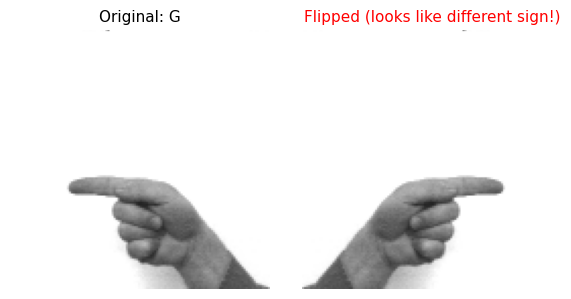

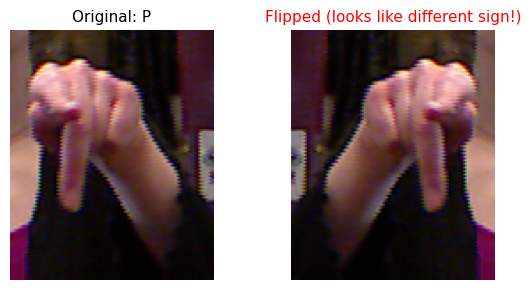

In [32]:
# Visual demonstration: show G and P original vs flipped
for cls in ['G', 'P']:
    sub = df[df['class_name'] == cls]
    if len(sub) == 0:
        continue
    path = sub.iloc[0]['filepath']
    img = Image.open(path).convert('RGB')
    flipped = img.transpose(Image.FLIP_LEFT_RIGHT)

    fig, axes = plt.subplots(1, 2, figsize=(6, 3))
    axes[0].imshow(img); axes[0].set_title(f'Original: {cls}', fontsize=11); axes[0].axis('off')
    axes[1].imshow(flipped); axes[1].set_title(f'Flipped (looks like different sign!)', fontsize=11, color='red'); axes[1].axis('off')
    plt.tight_layout()
    plt.show()

## 5. Class weights for imbalance-aware loss

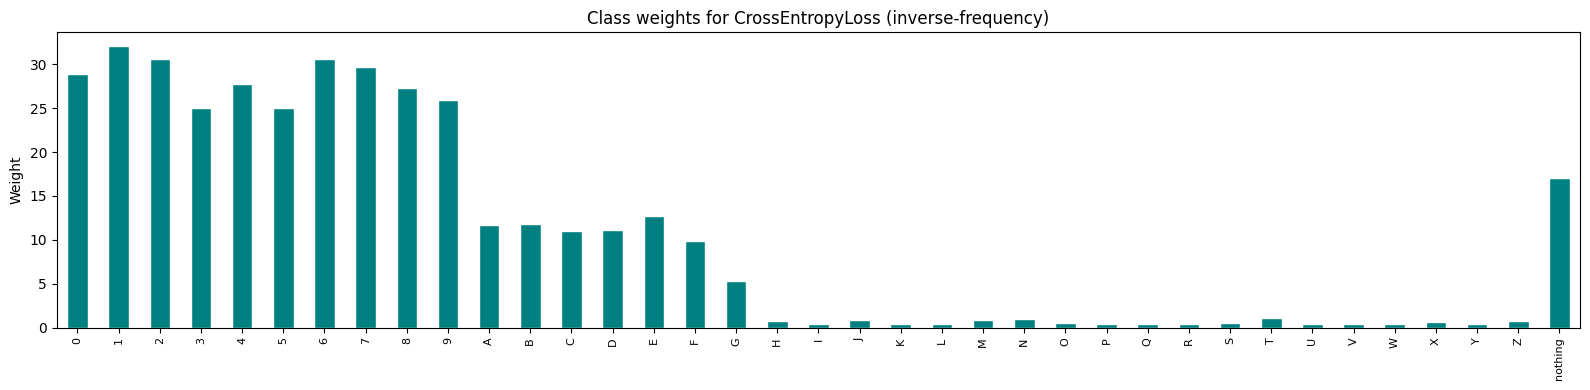

Weights (first 10 classes):
0    28.889608
1    32.049409
2    30.614361
3    25.014173
4    27.718408
5    25.014173
6    30.614361
7    29.726988
8    27.348829
9    25.964078
dtype: float64


In [33]:
train_csv = '..'/ cfg.data_root / 'splits' / 'asl_clean' / 'train.csv'
if not train_csv.exists():
    # fallback to flat splits dir
    train_csv = '..'/ cfg.data_root / 'splits' / 'train.csv'

if train_csv.exists():
    train_df = pd.read_csv(train_csv)
    counts = train_df.groupby('class_name').size().reindex(cfg.classes, fill_value=1).values.astype(float)
    weights = counts.sum() / (len(cfg.classes) * counts)
    weights_series = pd.Series(weights, index=cfg.classes)

    fig, ax = plt.subplots(figsize=(16, 4))
    weights_series.plot.bar(ax=ax, color='teal', edgecolor='white')
    ax.set_title('Class weights for CrossEntropyLoss (inverse-frequency)', fontsize=12)
    ax.set_ylabel('Weight')
    ax.tick_params(axis='x', labelsize=8, rotation=90)
    plt.tight_layout()
    plt.show()

    print('Weights (first 10 classes):')
    print(weights_series.head(10))
else:
    print('Run prepare_data.py first to generate splits.')

## 6. Raw dataset class counts per source

,combine_asl,asl_hg_raw,asl_alphabet,total
0,800,30,120,950
1,1020,30,100,1150
2,995,30,100,1125
3,995,30,100,1125
4,995,30,100,1125
5,995,30,100,1125
6,995,30,100,1125
7,995,30,100,1125
8,995,30,100,1125
9,995,30,100,1125


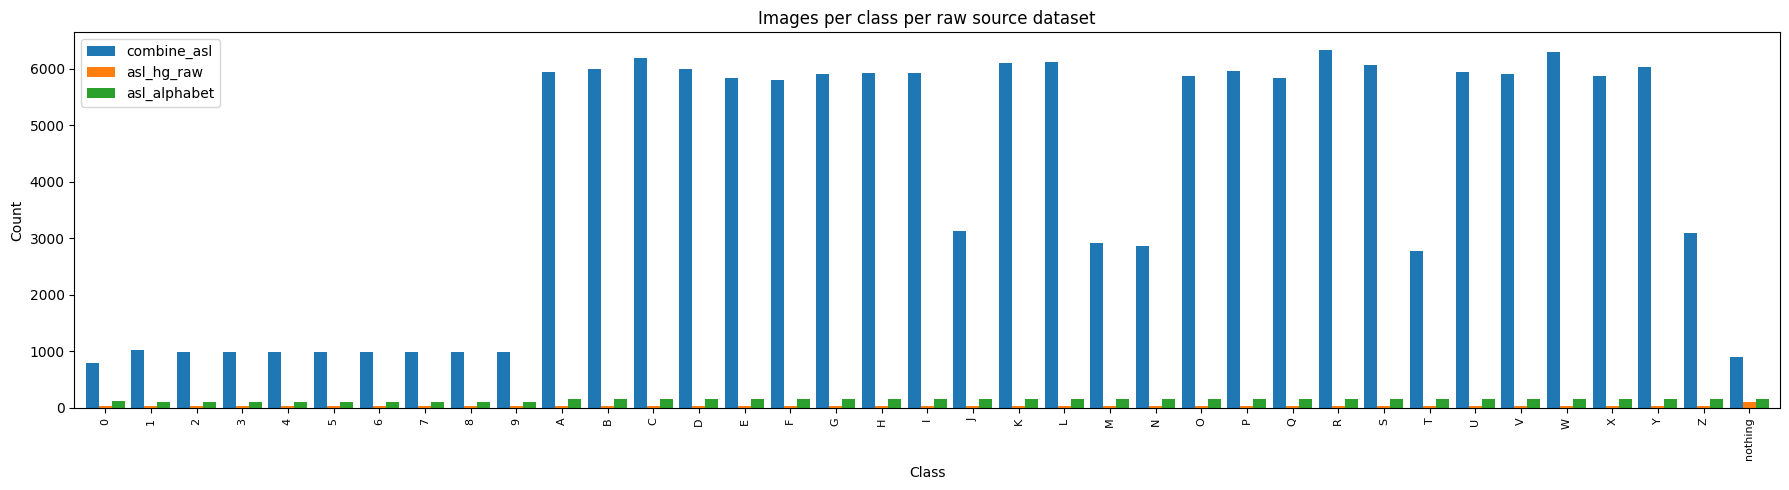


Total images across all datasets: 157,646
  combine_asl: 151,369 images, 37 classes
  asl_hg_raw: 1,180 images, 37 classes
  asl_alphabet: 5,097 images, 37 classes


In [34]:
from collections import defaultdict

IMAGE_EXTENSIONS = {'.jpg', '.jpeg', '.png', '.bmp', '.webp', '.tiff'}

counts = {}
for dataset_name, dataset_path in cfg.raw_dataset_paths.items():
    class_map = cfg.class_maps.get(dataset_name, {})
    if not dataset_path.exists():
        print(f'Not found: {dataset_path}')
        continue
    class_counts = defaultdict(int)
    for class_folder in sorted(dataset_path.iterdir()):
        if not class_folder.is_dir():
            continue
        canonical = class_map.get(class_folder.name)
        if canonical is None:
            continue
        n = sum(1 for f in class_folder.iterdir() if f.suffix.lower() in IMAGE_EXTENSIONS)
        class_counts[canonical] += n
    counts[dataset_name] = class_counts

if not counts:
    print('No raw datasets found. Check that cfg.raw_dataset_paths points to the correct directories.')
else:
    counts_df = pd.DataFrame(counts).reindex(cfg.classes, fill_value=0).fillna(0).astype(int)
    counts_df['total'] = counts_df.sum(axis=1)

    display(counts_df)

    dataset_cols = [c for c in counts_df.columns if c != 'total']
    fig, ax = plt.subplots(figsize=(18, 5))
    counts_df[dataset_cols].plot.bar(ax=ax, width=0.85)
    ax.set_title('Images per class per raw source dataset', fontsize=12)
    ax.set_xlabel('Class')
    ax.set_ylabel('Count')
    ax.tick_params(axis='x', labelsize=8, rotation=90)
    plt.tight_layout()
    plt.show()

    print(f'\nTotal images across all datasets: {counts_df["total"].sum():,}')
    for ds in dataset_cols:
        print(f'  {ds}: {counts_df[ds].sum():,} images, {(counts_df[ds] > 0).sum()} classes')